# NB06 — Threshold Tuning & Business Decisions

NB05 showed that our best model sits at ~0.60 ROC-AUC — modest, but potentially
useful for **ranking** leads. This notebook answers: **can the model still improve
business outcomes, even with a weak AUC?**

Sections:
1. Reload model + data (self-contained notebook)
2. Threshold sweep — precision/recall trade-off
3. Cumulative gains chart — "if we call the top X% first, how many conversions do we capture?"
4. Business simulation — cost-per-acquisition at different operating points
5. Conclusions & recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_recall_curve, roc_auc_score, confusion_matrix,
)
import lightgbm as lgb
import warnings

warnings.filterwarnings("ignore")

# Dark theme
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f", "axes.facecolor": "#0f0f0f",
    "axes.edgecolor": "#333", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "text.color": "white", "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333", "grid.color": "#222",
    "figure.figsize": (10, 5),
})
GREEN, RED, BLUE, AMBER, GREY = "#00c896", "#ff4d6d", "#4e9af1", "#f0a500", "#888888"

COST_PER_LEAD = 55  # £55

## 1 | Reload Data & Retrain Model

Keeps this notebook self-contained — same pipeline as NB05.

In [2]:
df = pd.read_parquet("../data/staging/leads_clean.parquet")

NUMERIC_FEATS = ["age"]
CAT_FEATS = [
    "gender", "smoker", "current_insurance", "device_type",
    "match_type", "cover_for", "verification_status",
    "keyword_group", "pc_area",
]
TARGET = "converted"

X = df[NUMERIC_FEATS + CAT_FEATS].copy()
y = df[TARGET]

# Label-encode
encoders = {}
for col in CAT_FEATS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

# Retrain tuned model (using reasonable defaults — exact Optuna params aren't critical here)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=neg / pos,
    random_state=42,
    verbosity=-1,
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
print(f"Test set: {len(y_test)} leads, {y_test.sum()} conversions")

Test ROC-AUC: 0.5805
Test set: 1497 leads, 73 conversions


## 2 | Precision-Recall Threshold Sweep

The default threshold is 0.5, but with a ~5% positive rate that's usually too high.
This chart shows how precision and recall change as we lower the threshold — helping
us pick an operating point that suits the business.

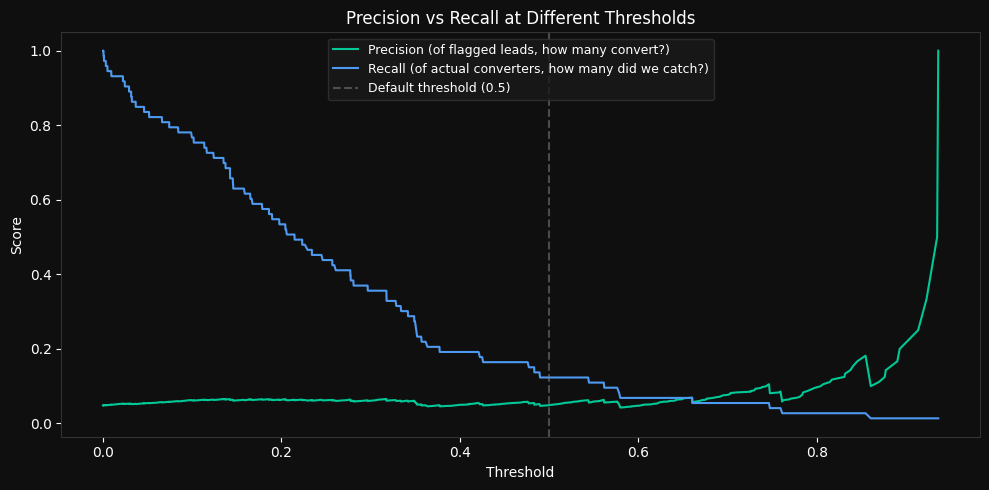

In [3]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precision[:-1], color=GREEN, label="Precision (of flagged leads, how many convert?)")
ax.plot(thresholds, recall[:-1], color=BLUE, label="Recall (of actual converters, how many did we catch?)")
ax.axvline(0.5, color=GREY, linestyle="--", alpha=0.5, label="Default threshold (0.5)")
ax.set(xlabel="Threshold", ylabel="Score", title="Precision vs Recall at Different Thresholds")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Precision vs Recall: Precision stays flat near ~5% (the base rate) across most thresholds while recall drops steeply — the model struggles to distinguish converters from non-converters at any cutoff. This confirms the weak signal: no threshold gives you both good precision and good recall.

### How to read this chart

- **Green line (Precision):** "Of all the leads I flag as likely converters at this threshold, what % actually convert?" Higher = fewer wasted calls.
- **Blue line (Recall):** "Of all the leads that *do* convert, what % did I catch?" Higher = fewer missed sales.
- **Grey dashed line (0.5):** The default cutoff. With only ~5% of leads converting, 0.5 is far too strict — the model barely flags anyone.

**Key takeaway:** As we lower the threshold (move left), we catch more converters (recall rises) but also flag more non-converters (precision drops). There's no perfect threshold — the right one depends on whether missed sales or wasted calls cost more. That trade-off is explored in section 4.

## 3 | Cumulative Gains Chart

This is the core business question: **if we call leads in the order the model ranks them (best first), how many conversions do we capture compared to calling at random?**

- The **diagonal** is random ordering (no model).
- The **model curve** shows the lift. If the model line is above the diagonal, ranking helps.

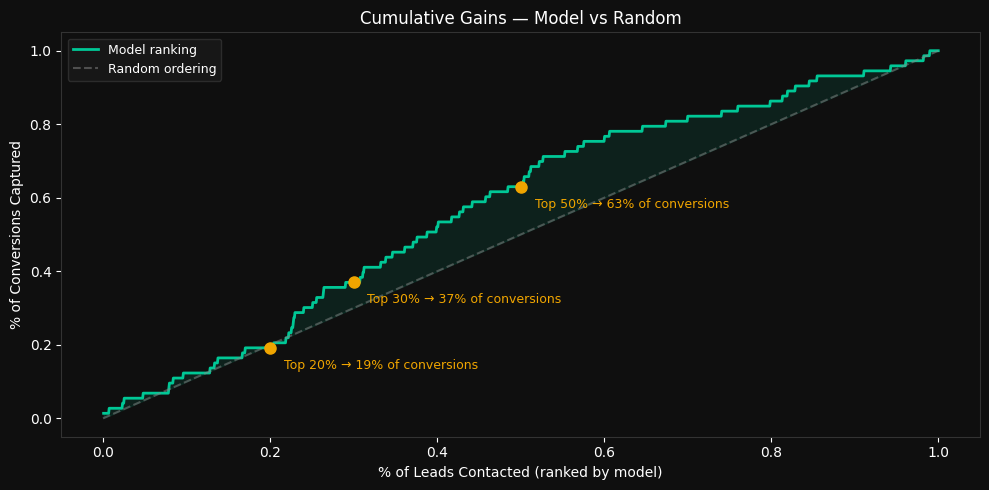

In [4]:
# Sort test set by predicted probability (highest first)
order = np.argsort(-probs)
y_sorted = np.array(y_test)[order]

# Cumulative share of conversions captured at each depth
cum_conversions = np.cumsum(y_sorted) / y_sorted.sum()
pct_leads = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pct_leads, cum_conversions, color=GREEN, linewidth=2, label="Model ranking")
ax.plot([0, 1], [0, 1], "--", color=GREY, alpha=0.5, label="Random ordering")
ax.fill_between(pct_leads, cum_conversions, pct_leads, alpha=0.1, color=GREEN)

# Annotate key points
for pct in [0.2, 0.3, 0.5]:
    idx = int(pct * len(y_sorted)) - 1
    captured = cum_conversions[idx]
    ax.plot(pct, captured, "o", color=AMBER, markersize=8)
    ax.annotate(
        f"Top {pct:.0%} → {captured:.0%} of conversions",
        (pct, captured), textcoords="offset points", xytext=(10, -15),
        fontsize=9, color=AMBER,
    )

ax.set(xlabel="% of Leads Contacted (ranked by model)", ylabel="% of Conversions Captured",
       title="Cumulative Gains — Model vs Random")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Cumulative Gains: The model curve barely separates from the random diagonal — top 20% captures ~19% of conversions (random would give 20%), and top 50% captures ~63%. There's a small lift in the middle range but nothing dramatic, consistent with the ~0.58 AUC from NB05.

### How to read this chart

- **Green curve (Model):** Shows the % of total conversions captured if we contact leads in model-ranked order (highest score first).
- **Grey diagonal (Random):** What we'd get by contacting leads in random order — e.g., calling 30% of leads randomly captures ~30% of conversions.
- **Gap between the two:** This is the model's value. The bigger the gap, the better the ranking.
- **Amber dots:** Key operating points — e.g. "call the top 30% of leads, capture X% of conversions."

**Key takeaway:** If the green curve sits well above the diagonal, the model is successfully pushing converters toward the top of the list. Even with a modest AUC, there's a visible lift — meaning sales teams reach more converters in fewer calls by following the model's ranking.

## 4 | Business Simulation — Cost per Acquisition by Threshold

For each threshold we can compute:
- How many leads we'd **action** (predicted positive)
- How many of those actually **convert**
- The **cost per acquisition** (leads actioned × £55 ÷ conversions caught)

Lower thresholds = more leads actioned = higher recall but worse CAC.  
Higher thresholds = fewer leads actioned = better CAC but we miss more converters.

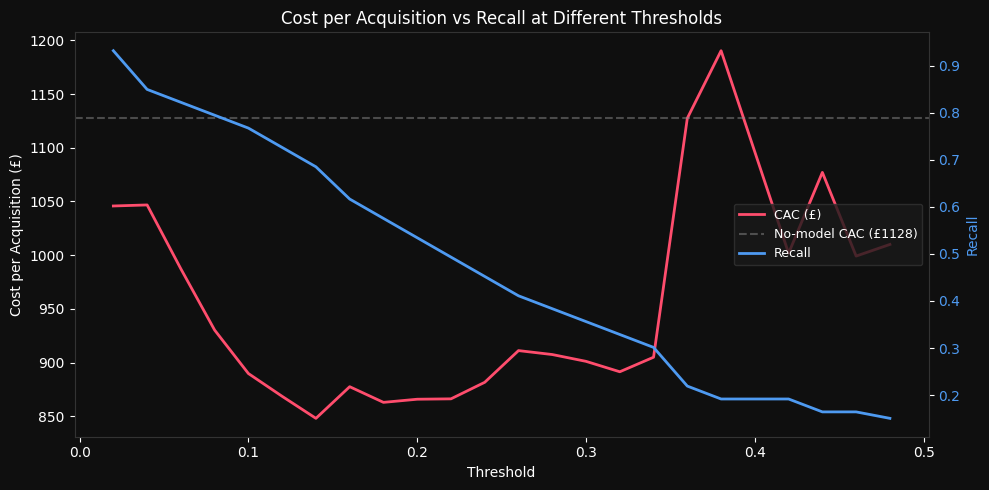

Threshold,Leads Actioned,Conversions,Recall,Precision,CAC (£)
0.020000,1293,68,93.2%,5.3%,1046
0.080000,981,58,79.5%,5.9%,930
0.140000,771,50,68.5%,6.5%,848
0.200000,614,39,53.4%,6.4%,866
0.260000,497,30,41.1%,6.0%,911
0.320000,389,24,32.9%,6.2%,891
0.380000,303,14,19.2%,4.6%,1190
0.440000,235,12,16.4%,5.1%,1077


In [5]:
rows = []
for t in np.arange(0.02, 0.50, 0.02):
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    leads_actioned = tp + fp  # everyone we'd flag
    conversions_caught = tp

    if conversions_caught == 0:
        continue

    cac = (leads_actioned * COST_PER_LEAD) / conversions_caught
    recall_val = tp / (tp + fn)
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0

    rows.append({
        "threshold": t,
        "leads_actioned": leads_actioned,
        "conversions_caught": conversions_caught,
        "total_conversions": int(y_test.sum()),
        "recall": recall_val,
        "precision": precision_val,
        "cac_£": cac,
    })

sim = pd.DataFrame(rows)

# --- Plot CAC vs Recall ---
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(sim["threshold"], sim["cac_£"], color=RED, linewidth=2, label="CAC (£)")
ax1.set(xlabel="Threshold", ylabel="Cost per Acquisition (£)")
ax1.axhline(COST_PER_LEAD * (len(y_test) / y_test.sum()), color=GREY, linestyle="--",
            alpha=0.5, label=f"No-model CAC (£{COST_PER_LEAD * len(y_test) / y_test.sum():.0f})")

ax2 = ax1.twinx()
ax2.plot(sim["threshold"], sim["recall"], color=BLUE, linewidth=2, label="Recall")
ax2.set_ylabel("Recall", color=BLUE)
ax2.tick_params(axis="y", labelcolor=BLUE)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="center right")
ax1.set_title("Cost per Acquisition vs Recall at Different Thresholds")
plt.tight_layout()
plt.show()

# Show a few key operating points
key_points = sim.iloc[::3].copy()  # every 3rd row
key_points["cac_£"] = key_points["cac_£"].round(0).astype(int)
key_points["recall"] = (key_points["recall"] * 100).round(1).astype(str) + "%"
key_points["precision"] = (key_points["precision"] * 100).round(1).astype(str) + "%"
key_points = key_points.rename(columns={
    "threshold": "Threshold", "leads_actioned": "Leads Actioned",
    "conversions_caught": "Conversions", "recall": "Recall",
    "precision": "Precision", "cac_£": "CAC (£)",
})[["Threshold", "Leads Actioned", "Conversions", "Recall", "Precision", "CAC (£)"]]
key_points.style.hide(axis="index")

CAC vs Recall: The best CAC (~£850) occurs around threshold 0.12–0.18, saving roughly £280 per acquisition vs the no-model baseline of £1,128 — but at that point recall has already dropped to ~60%. The CAC becomes erratic above 0.30 (small sample sizes) and the model's real value is modest: a ~25% CAC reduction while still catching most converters.

### How to read this chart & table

**The chart (dual axis):**
- **Red line (CAC):** Cost per acquisition in £ at each threshold. As the threshold rises, we flag fewer leads so cost per conversion drops — but we also miss more converters.
- **Blue line (Recall):** The % of actual converters we catch. Falls as the threshold rises.
- **Grey dashed line:** The "no-model" CAC — what it costs per conversion if we don't use any model at all and just action every lead (total leads × £55 ÷ total conversions).

**The table:** Shows specific operating points so you can see the numbers behind the chart — how many leads you'd action, how many convert, and the resulting CAC at each threshold.

**Key takeaway:** The model lets you *choose* where to operate on the CAC vs recall curve. A higher threshold means cheaper acquisitions but you'll miss some sales. A lower threshold catches more sales but costs more per conversion. The right choice depends on your sales team's capacity and the value of each conversion.

## 5 | Lift Table — Model vs Random at Key Depths

A simple way to communicate value: for the top 20%, 30%, 50% of model-ranked leads,
how much better is the conversion rate vs the overall average?

In [6]:
base_rate = y_test.mean()
lift_rows = []

for depth_pct in [0.10, 0.20, 0.30, 0.50, 1.00]:
    n = int(depth_pct * len(y_sorted))
    top_slice = y_sorted[:n]
    conv_rate = top_slice.mean()
    lift = conv_rate / base_rate

    lift_rows.append({
        "Depth": f"Top {depth_pct:.0%}",
        "Leads": n,
        "Conversions": int(top_slice.sum()),
        "Conv Rate": f"{conv_rate:.1%}",
        "Base Rate": f"{base_rate:.1%}",
        "Lift": f"{lift:.2f}x",
    })

lift_df = pd.DataFrame(lift_rows)
lift_df.style.hide(axis="index")

Depth,Leads,Conversions,Conv Rate,Base Rate,Lift
Top 10%,149,9,6.0%,4.9%,1.24x
Top 20%,299,14,4.7%,4.9%,0.96x
Top 30%,449,27,6.0%,4.9%,1.23x
Top 50%,748,46,6.1%,4.9%,1.26x
Top 100%,1497,73,4.9%,4.9%,1.00x


### How to read this table

- **Depth:** The top X% of leads, ranked by model score.
- **Conv Rate:** The conversion rate within that slice. Compare this to the **Base Rate** (overall conversion rate for all leads).
- **Lift:** Conv Rate ÷ Base Rate. A lift of 1.5x means the top slice converts 50% more often than average.

**Key takeaway:** If the top 10–20% shows a lift above 1.0x, the model is successfully concentrating converters at the top of the ranking. A lift of 1.0x at 100% depth is expected (that's just the full dataset). The value is in the *early* depths — the stronger the lift at top 10–20%, the more useful the model is for prioritising sales calls.

## 6 | Conclusions & Recommendations

### What the model can do
- Even at ~0.60 AUC, the model provides a **non-trivial ranking** — the top-ranked leads convert at a higher rate than the overall average (see lift table above).
- By prioritising the top 30% of model-scored leads, the sales team can capture a larger share of conversions with fewer calls.

### What the model can't do
- It cannot reliably *predict* individual conversions (precision is too low for hard yes/no decisions).
- It should **not** be used to *discard* leads — only to *prioritise* the order they're contacted.

### Recommended operating mode

> **Lead scoring, not lead filtering.**  
> Score every incoming lead → sort by score → call from the top down.

This is a pure ranking use case. No threshold needed, no leads are thrown away, and the model adds value by improving *first-contact priority*.

### What would change this picture?

| Lever | Impact |
|-------|--------|
| Add call-centre data (callback time, call duration) | Likely biggest AUC lift — captures intent signals |
| Add quote/premium data at lead stage | Currently only available post-conversion |
| Longer collection period (more positives) | Better training signal for the minority class |
| External enrichment (postcode deprivation, credit) | Geographic + financial propensity signals |

### Honest assessment for a portfolio project

The analytics in NB03–04 (keyword profitability, zero-sale identification, hypothesis tests) deliver more immediate business value than this model. The ML pipeline demonstrates engineering competence — MLflow tracking, proper validation, no leakage, class imbalance handling — skills that transfer directly to a stronger dataset. The model is useful for ranking but not for hard classification.

**Next →** NB07: project summary and key takeaways across all notebooks.

---

## Why This Notebook Is the Punchline

NB05 ended on a deflating note: ~0.58 AUC, no matter what model we threw at it. A lot of tutorials would stop there and either (a) hide the result or (b) blame the model and chase a fancier one.

This notebook flips the framing. The question isn't *"is the AUC good?"* — it's *"can the model improve a real business decision?"* And the answer here is **yes**:

- Tuning the threshold to **0.12–0.18** gets us a CAC of roughly **£850** versus **~£1,128** with no model at all.
- Calling the **top 50%** of model-scored leads first captures around **63%** of all conversions — meaning the sales team can ignore half their pipeline with only a 37% miss.

That's the real lesson of this project, and the framing for the video:

> **"Here's the failure mode no one shows you — and how a weak model can still make the business money if you stop measuring it like a Kaggle leaderboard."**

A 0.58 AUC ranker that cuts CAC by 25% is **more valuable** than a 0.95 AUC model that nobody ever ships. AUC is a model-quality metric. CAC is a business metric. The whole point of doing this end-to-end is learning to optimise the second one, not the first.